In [1]:
# Importación de librerías necesarias
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [2]:
# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [3]:
# Lectura del dataset desde la base de datos
query = "SELECT * FROM hospital_performance_final"

df = pd.read_sql(query, engine)
df.head()

,hospital_id,hospital_name,sector,city,province,hospital_type,year,total_beds,icu_beds,operation_theatres,emergency_department,diagnostic_labs,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,insurance_accepted,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,ambulance_available,telemedicine_service,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
0,H10000,Hospital_TSDGA,Public,Sialkot,Punjab,Specialized,2024,1432,49,6,Yes,No,5.3,331,120,799,269,0.001418,2367,775,260,3.2,692,976.0,621.0,39060.0,29429077.0,Yes,5.1,2.24,3.34,8.49,31,8.2,Yes,No,49.0,2392.833333,0,0.034218,0.138330,43.333333,1399.0,0.584663,0.342,0.826,0.990,0.617
1,H10001,Hospital_VAXQQ,Private,Quetta,Balochistan,General,2023,905,29,4,No,No,8.5,271,36,381,38,0.001547,642,1488,101,3.7,61,3614.0,2516.0,31821.0,0.0,Yes,7.3,0.66,6.70,7.76,5,29.1,No,Yes,15.0,691.600000,0,0.032044,0.391845,25.250000,690.0,0.997687,0.443,0.871,0.937,0.670
2,H10002,Hospital_XABQD,Public,Kasur,Punjab,Specialized,2024,456,141,20,Yes,Yes,6.8,135,90,83,212,0.000927,992,928,331,4.6,16,6865.0,252.0,45706.0,38516209.0,No,7.9,4.71,4.07,7.39,179,3.7,Yes,No,68.0,1022.933333,0,0.309211,0.131973,16.550000,430.0,0.420360,0.362,0.321,0.871,0.452
3,H10003,Hospital_AYNGM,Public,Sheikhupura,Punjab,Specialized,2023,890,121,1,No,Yes,7.5,216,101,115,253,0.001625,921,170,162,4.7,257,12006.0,276.0,75900.0,35923243.0,No,7.5,3.95,5.32,9.41,116,39.1,Yes,Yes,45.0,926.666667,0,0.135955,0.233094,162.000000,584.0,0.630216,0.278,0.495,0.767,0.441
4,H10004,Hospital_ZRAVI,Public,Sheikhupura,Punjab,Specialized,2022,978,72,17,Yes,Yes,7.4,381,43,474,65,0.000704,1555,591,283,7.7,690,875.0,530.0,73349.0,32512196.0,Yes,9.1,4.88,0.96,3.15,99,18.4,Yes,No,15.0,1574.700000,0,0.073620,0.241951,16.647059,920.0,0.584238,0.657,0.367,0.992,0.637


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hospital_id                 5500 non-null   object 
 1   hospital_name               5500 non-null   object 
 2   sector                      5500 non-null   object 
 3   city                        5500 non-null   object 
 4   province                    5500 non-null   object 
 5   hospital_type               5500 non-null   object 
 6   year                        5500 non-null   int64  
 7   total_beds                  5500 non-null   int64  
 8   icu_beds                    5500 non-null   int64  
 9   operation_theatres          5500 non-null   int64  
 10  emergency_department        5500 non-null   object 
 11  diagnostic_labs             5500 non-null   object 
 12  medical_equipment_score     5500 non-null   float64
 13  total_doctors               5500 

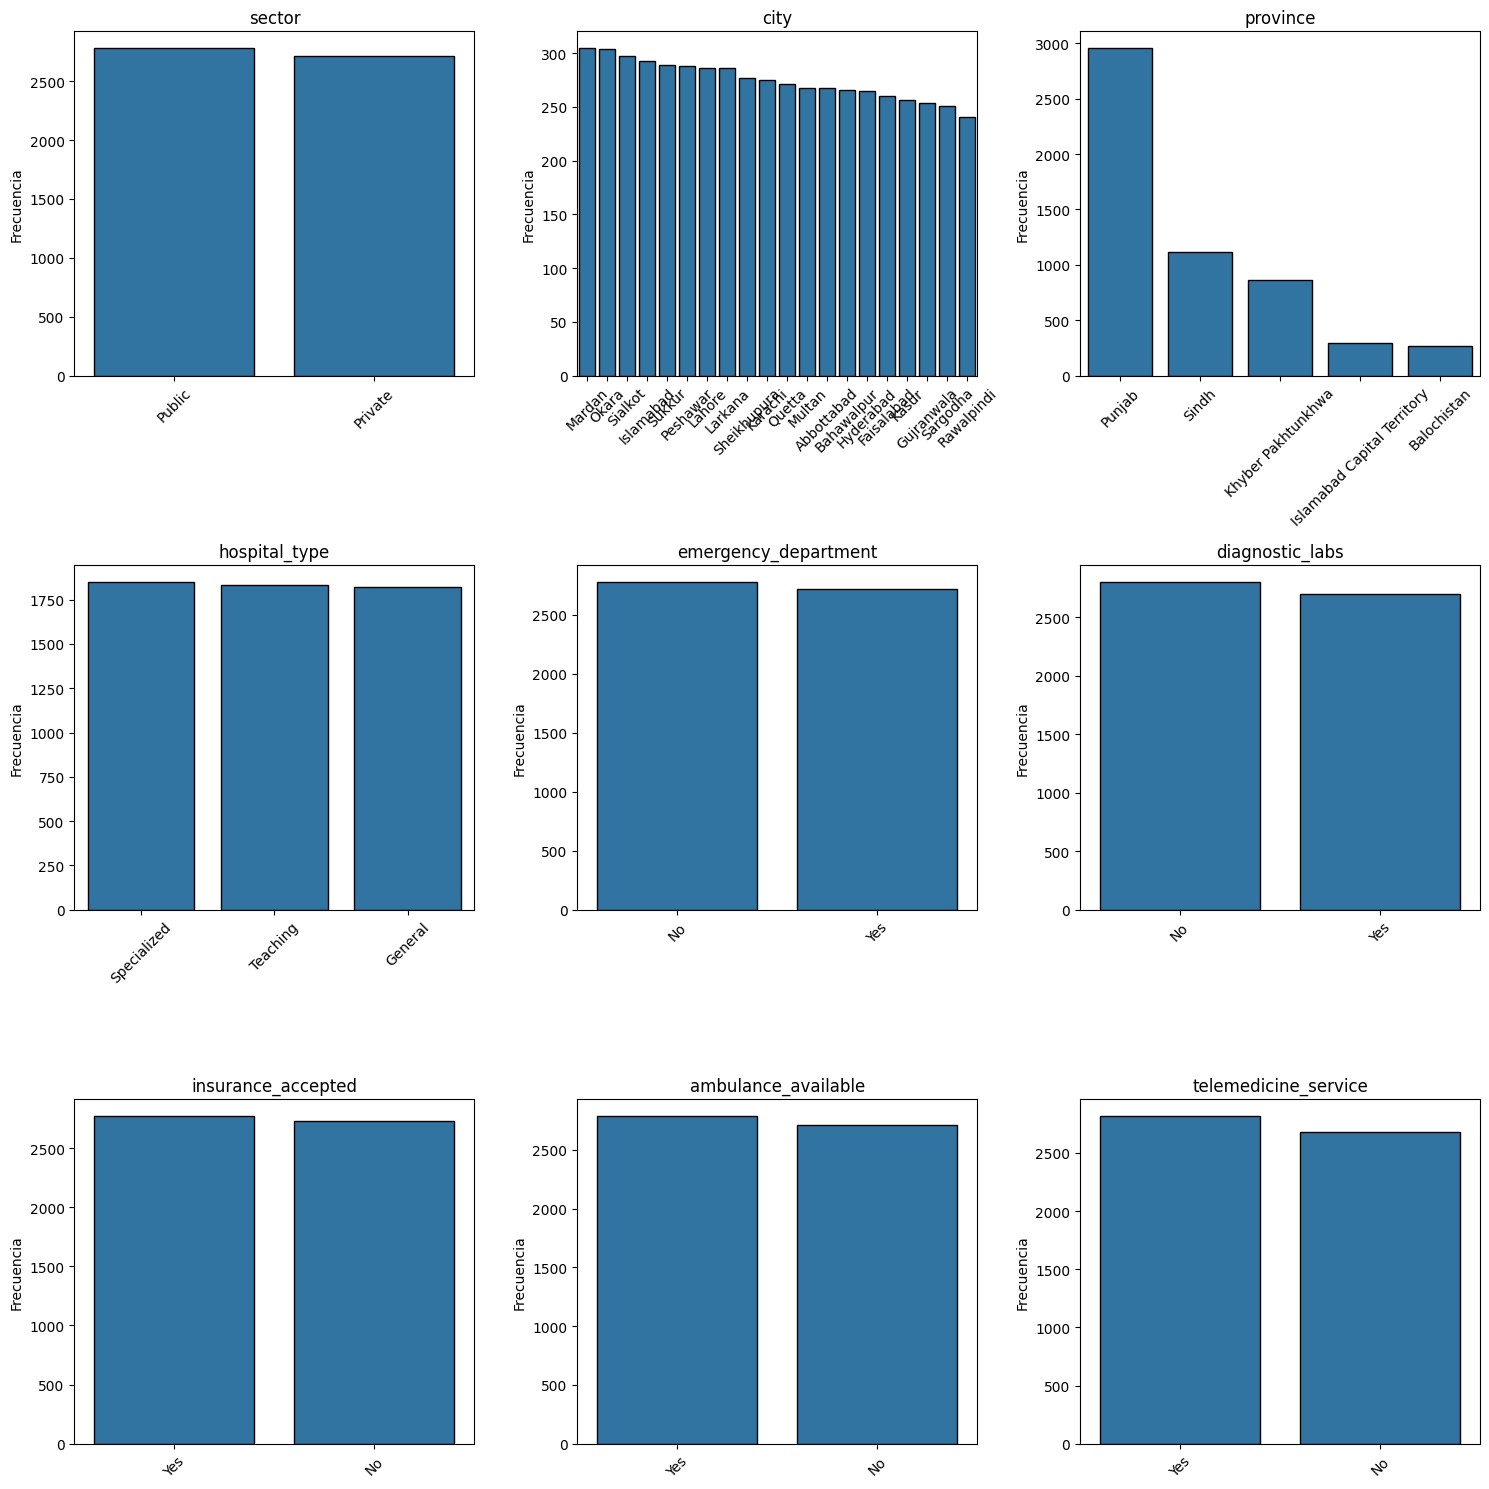

In [5]:
# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro recomendable
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    value_counts = df[col].value_counts()
    
    sns.barplot(x=value_counts.index, y=value_counts.values, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

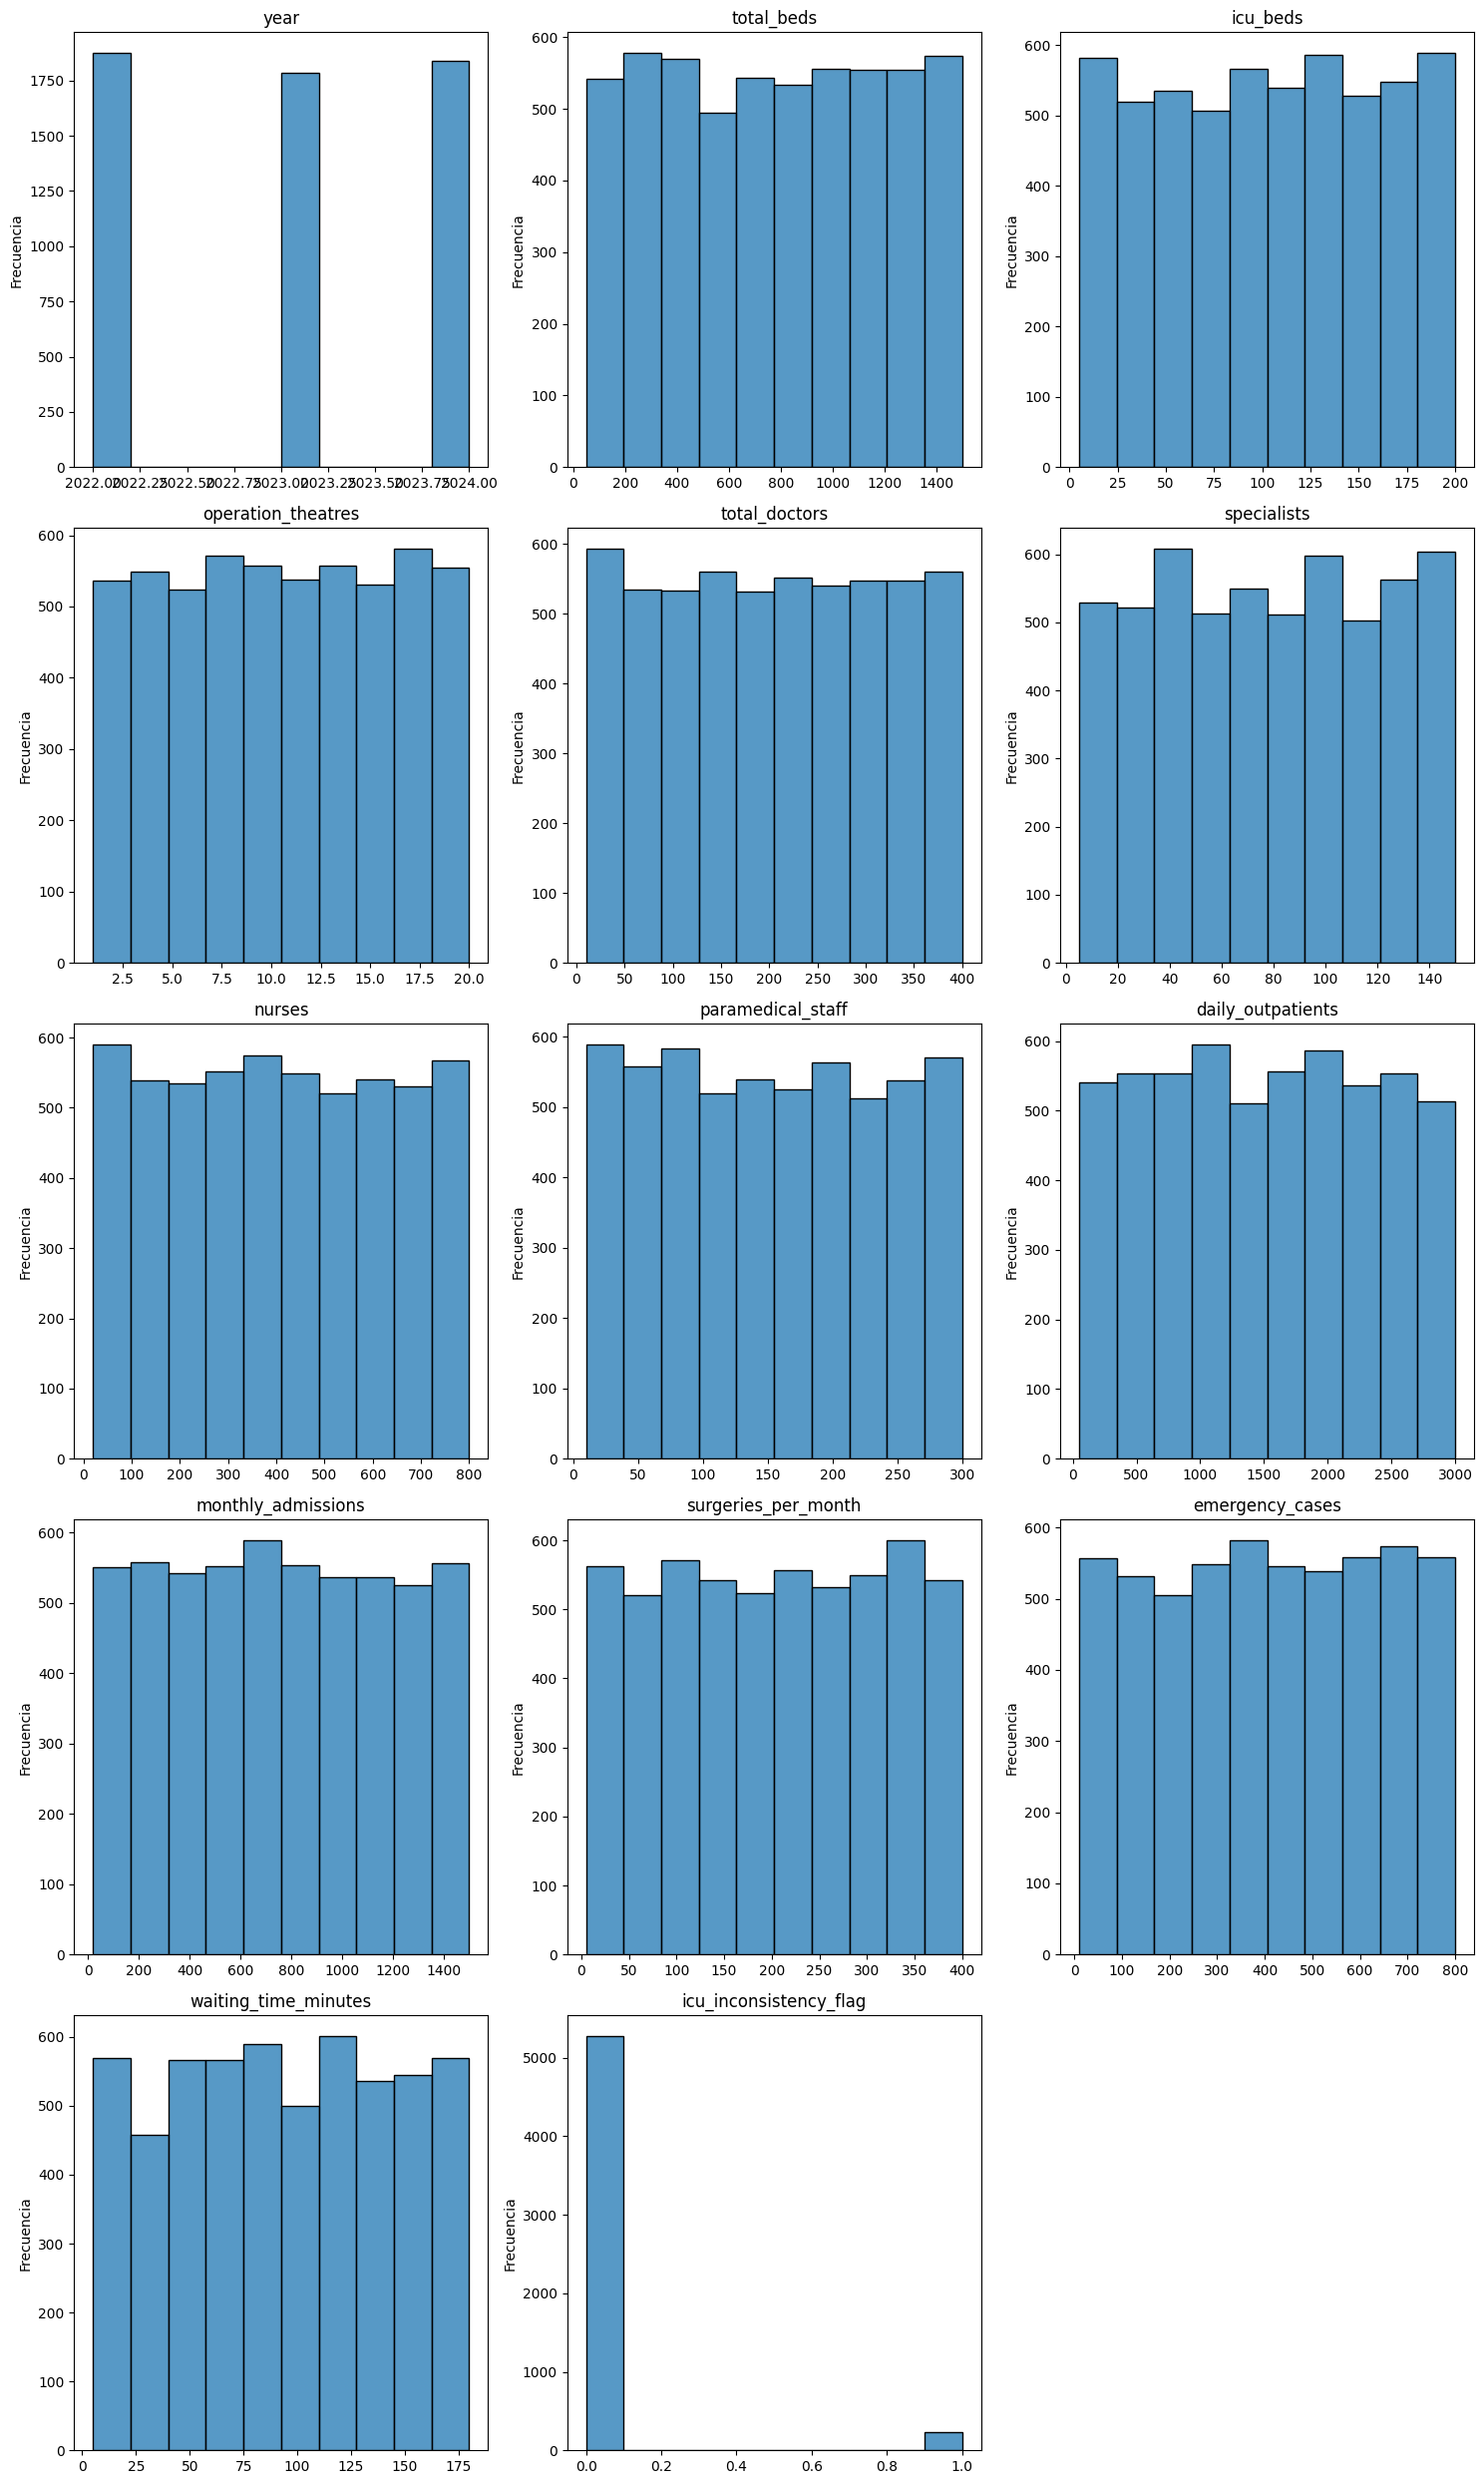

In [6]:
# seleccionar variables enteras
int_cols = df.select_dtypes(include=["int64", "int32"]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    data = df[col].dropna()
    
    sns.histplot(data, bins=10, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

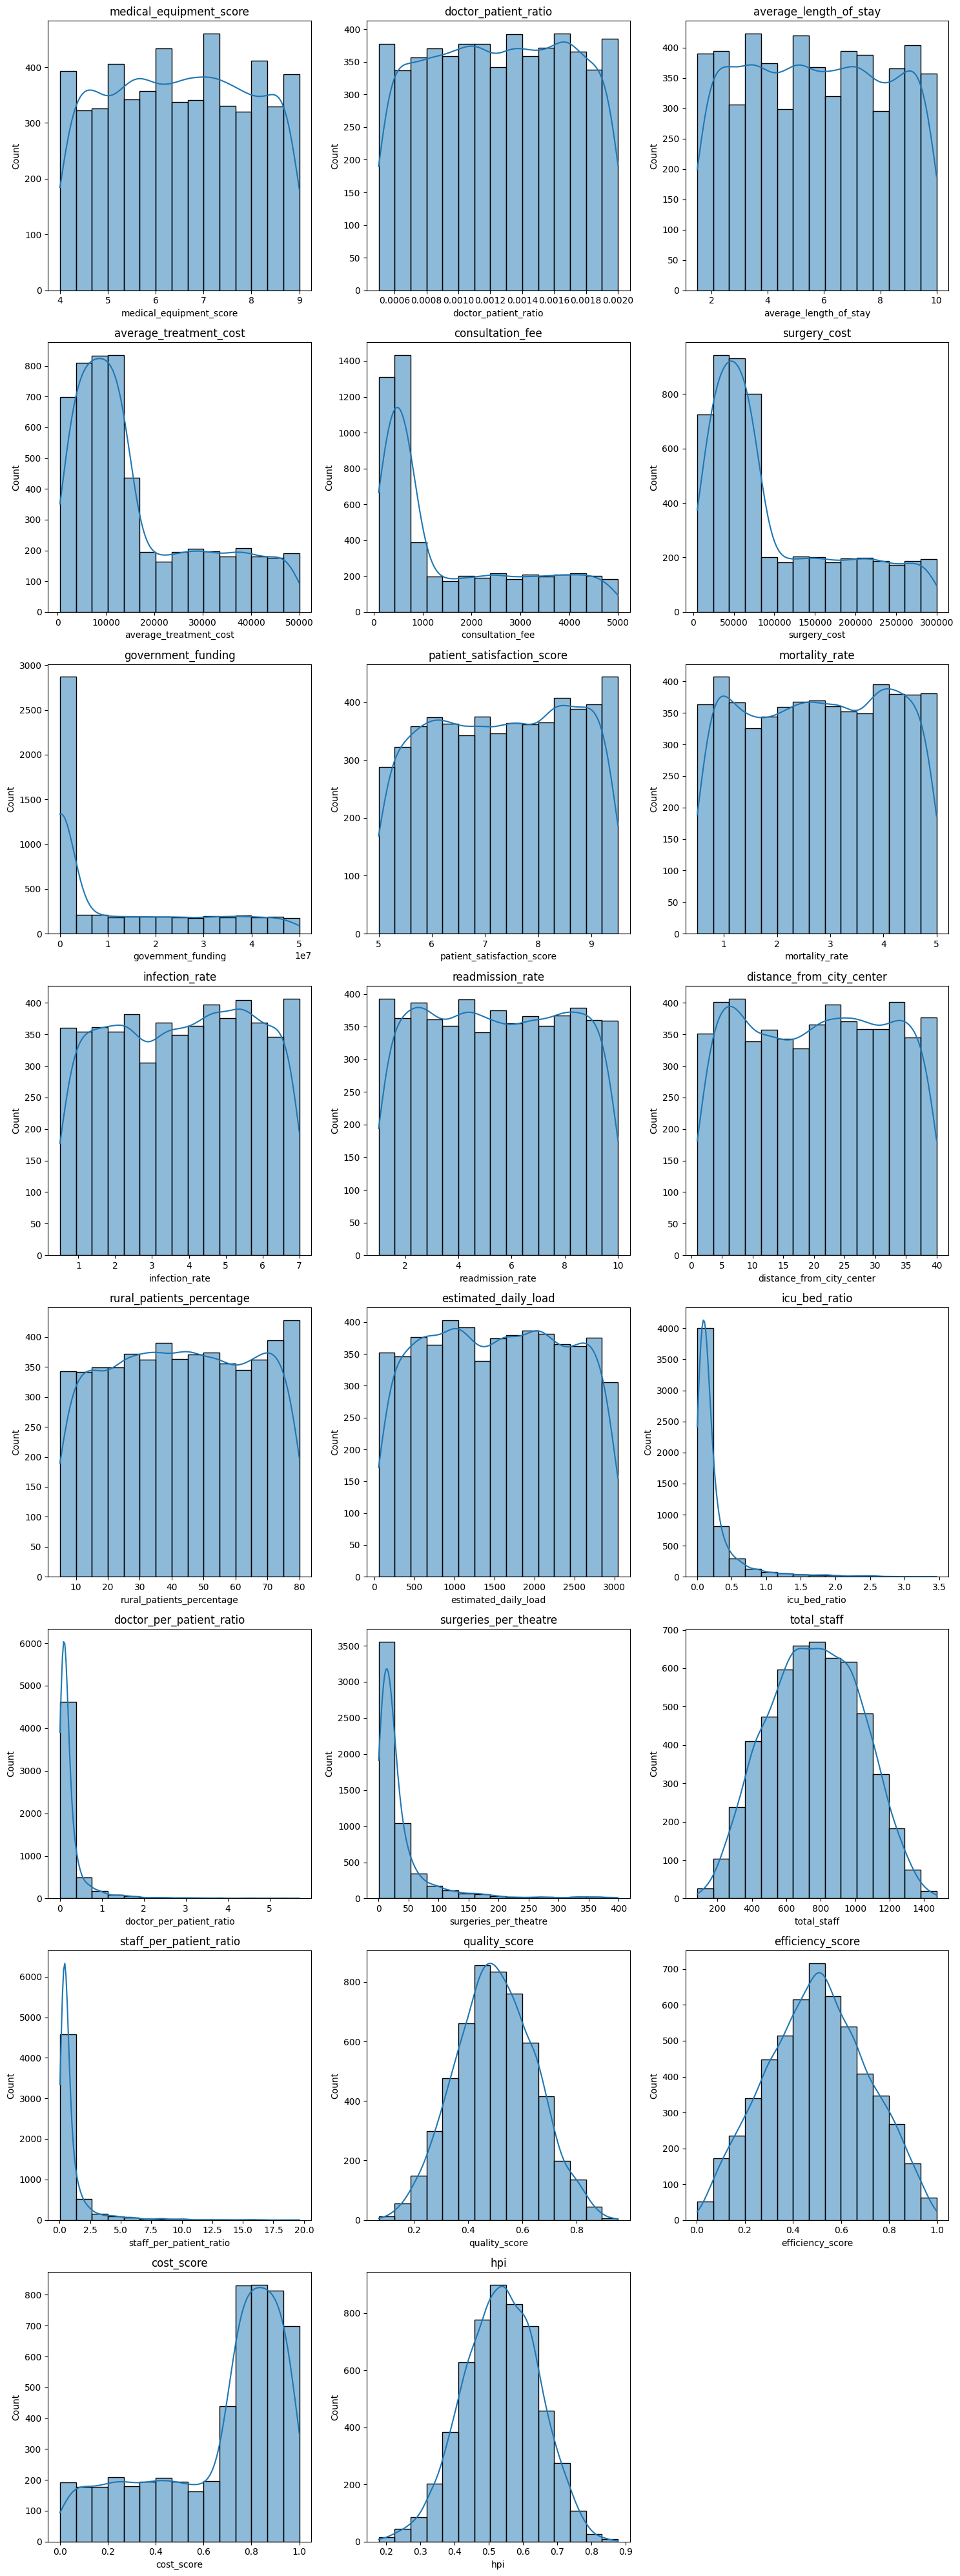

In [7]:
# seleccionar variables continuas (float)
float_cols = df.select_dtypes(include=["float64", "float32"]).columns

n_cols = 3  # ajustable
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]
    
    data = df[col].dropna()

    sns.histplot(data, bins=15, edgecolor="black", kde=True, ax=ax)
    
    ax.set_title(col)

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

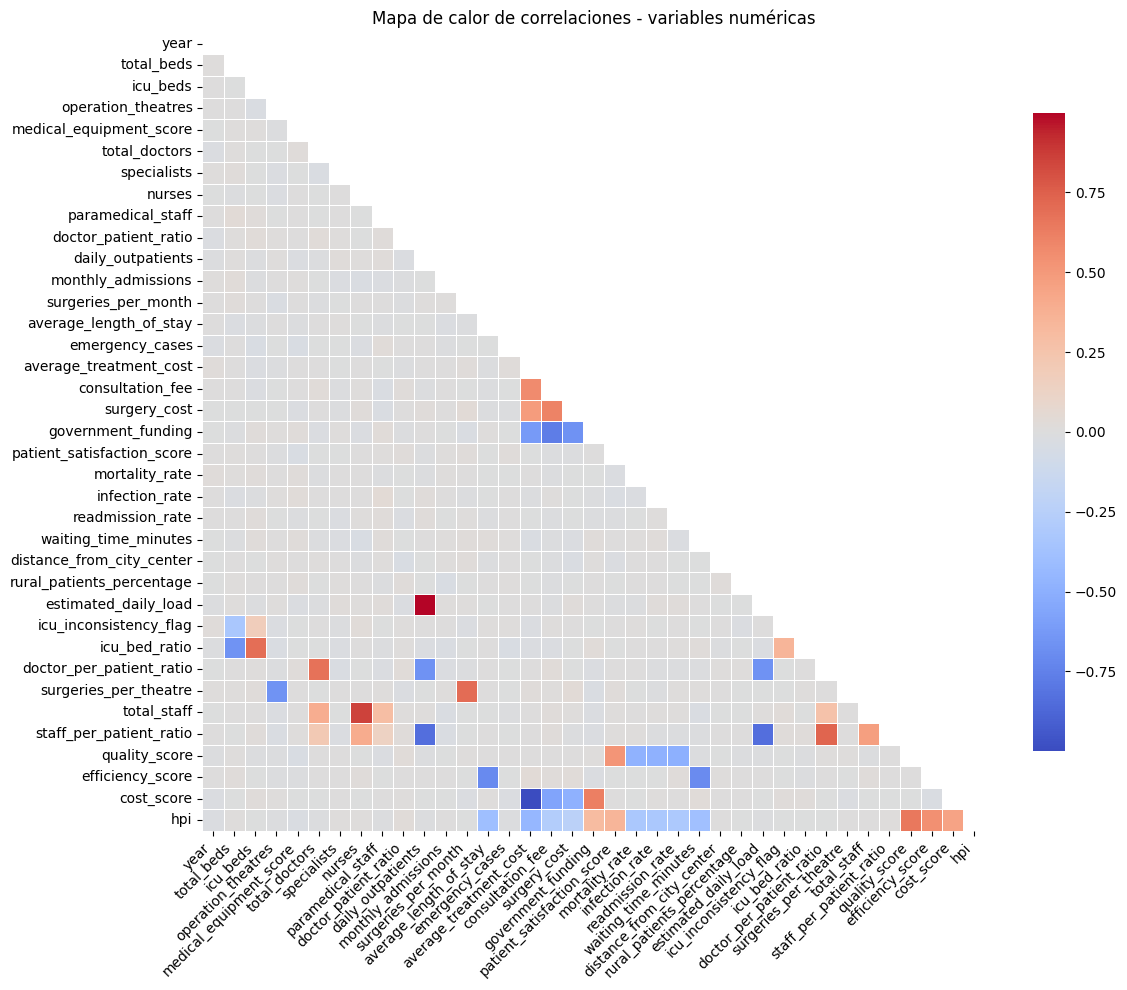

In [8]:
num_cols = df.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns

corr_matrix = df[num_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de calor de correlaciones - variables numéricas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df['government_funding'], df["hpi"])

print("Correlación de Spearman:")
print(corr)
print("P-value:")
print(p_value)

Correlación de Spearman:
0.3113047322133147
P-value:
6.944946369422303e-124


In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop("hpi")

results = []
for col in numeric_cols:
    corr, p_value = spearmanr(df[col], df["hpi"])
    results.append({
        "variable": col,
        "spearman_corr": corr,
        "p_value": p_value,
        "significant": p_value < 0.1
    })

spearman_top = (
    pd.DataFrame(results)
      .sort_values(by="spearman_corr", key=lambda x: x.abs(), ascending=False)
      .reset_index(drop=True)
)

spearman_top.head(20)

,variable,spearman_corr,p_value,significant
0,quality_score,0.648917,0.000000e+00,True
1,efficiency_score,0.540813,0.000000e+00,True
2,average_treatment_cost,-0.445548,1.561474e-266,True
3,cost_score,0.445539,1.606484e-266,True
4,average_length_of_stay,-0.395914,7.771256e-206,True
5,waiting_time_minutes,-0.385238,4.487411e-194,True
6,patient_satisfaction_score,0.344711,2.942232e-153,True
7,mortality_rate,-0.327265,1.862749e-137,True
8,infection_rate,-0.325906,2.872338e-136,True
9,readmission_rate,-0.316265,5.162666e-128,True


In [11]:
selected_vars = [
    "government_funding",
    "consultation_fee",
    "surgery_cost",
    "doctor_per_patient_ratio",
    "medical_equipment_score",
    "total_beds",
    "specialists",
    "nurses",
]

MSE:  0.011084
RMSE: 0.105281
R2:   0.063108

Importancia de variables:
government_funding          0.168958
doctor_per_patient_ratio    0.131112
consultation_fee            0.123753
surgery_cost                0.123178
total_beds                  0.123063
nurses                      0.120704
specialists                 0.115013
medical_equipment_score     0.094220
dtype: float64


C:\Users\Estudio\AppData\Local\Temp\ipykernel_8648\1240192022.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
C:\Users\Estudio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Estudio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

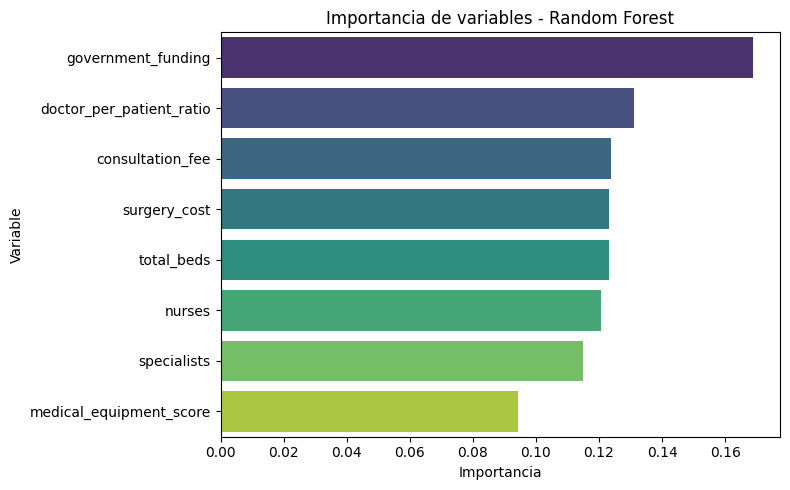

In [12]:
from sklearn.ensemble import RandomForestRegressor

X = df[selected_vars]
y = df["hpi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2:   {r2:.6f}")

feature_importances = pd.Series(rf.feature_importances_, index=selected_vars).sort_values(ascending=False)
print("\nImportancia de variables:")
print(feature_importances)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

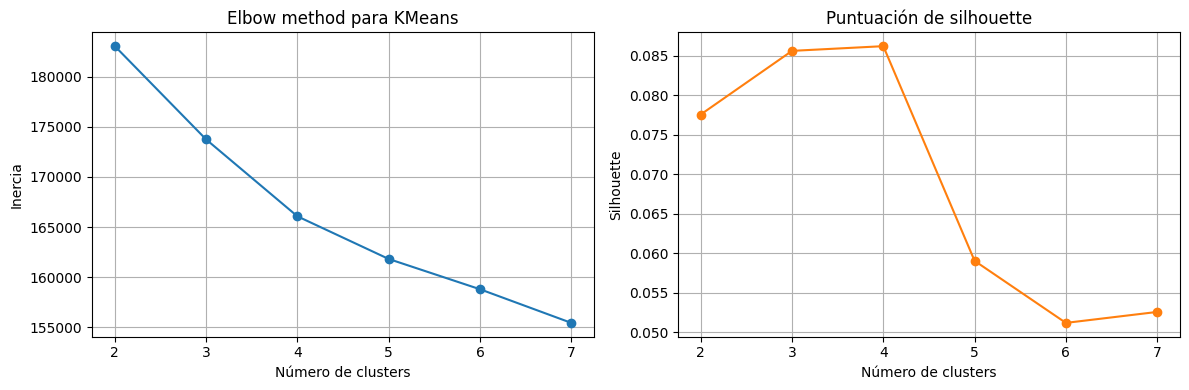

Mejor número de clusters según silhouette: 4
cluster
0    2204
1    2610
2     223
3     463
Name: count, dtype: int64


,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2022.990,814.208,98.972,10.453,6.461,202.093,77.275,405.951,150.149,0.001,1625.005,757.441,206.015,5.630,407.838,28170.110,2856.576,166002.260,0.000000e+00,7.295,2.765,3.856,5.450,91.466,20.222,43.092,1650.253,0.000,0.178,0.166,36.480,758.193,0.638,0.499,0.510,0.441,0.491
1,2022.989,798.745,102.057,10.757,6.515,198.033,79.003,394.256,155.121,0.001,1648.713,759.417,201.424,5.712,409.398,7791.751,532.451,46299.548,2.320310e+07,7.314,2.754,3.779,5.474,94.517,20.665,42.667,1674.027,0.000,0.188,0.157,35.366,747.410,0.601,0.503,0.496,0.853,0.571
2,2023.072,100.287,151.404,9.982,6.457,205.054,74.744,443.372,149.762,0.001,1544.215,770.395,189.332,5.800,417.946,16043.448,1659.709,102233.471,1.301980e+07,7.332,2.826,3.718,5.538,92.377,20.400,40.767,1569.895,1.000,1.630,0.234,35.210,798.188,0.902,0.501,0.497,0.686,0.537
3,2023.002,816.127,105.343,10.251,6.572,247.683,78.302,469.933,156.251,0.001,207.400,712.559,207.654,6.043,398.924,14977.430,1508.782,93375.527,1.282356e+07,7.269,2.761,3.734,5.420,91.337,20.623,44.013,231.152,0.006,0.189,1.320,36.978,873.866,4.875,0.503,0.486,0.707,0.539


In [13]:
from sklearn.metrics import silhouette_score

# seleccionar variables numéricas para clusterización
features_clust = numeric_cols.tolist()
X_clust = df[features_clust]

# estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# método del codo y silhouette para elegir k
k_values = range(2, 8)
inertia = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow method para KMeans")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='tab:orange')
plt.title("Puntuación de silhouette")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(silhouette_scores))]
print("Mejor número de clusters según silhouette:", best_k)

# ajustar modelo final y agregar etiquetas al dataset
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clustered = df.copy()
df_clustered["cluster"] = kmeans.fit_predict(X_scaled)

print(df_clustered["cluster"].value_counts().sort_index())

cluster_profile = (
    df_clustered.groupby("cluster")[features_clust + ["hpi"]]
    .mean()
    .round(3)
)

cluster_profile

In [14]:
import plotly.express as px

fig = px.scatter_3d(
    df_clustered,
    x="consultation_fee",
    y="daily_outpatients",
    z="total_beds",
    color="cluster",
    hover_data=["hospital_name", "province", "city", "hpi"],
    title="Clusters 3D: consultation_fee vs daily_outpatients vs icu_beds"
)

fig.update_traces(marker=dict(size=4))
fig.show()

## Regresion lineal con step forwards-backwar FALLIDA

In [15]:
X = df[selected_vars]
y = df["hpi"]

def stepwise_selection(X, y, initial_list=None, threshold_in=0.1, threshold_out=0.1, verbose=True):
    if initial_list is None:
        included = []
    else:
        included = list(initial_list)

    while True:
        changed = False

        excluded = [col for col in X.columns if col not in included]
        new_pvalues = pd.Series(index=excluded, dtype=float)

        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            new_pvalues[col] = model.pvalues[col]

        if not new_pvalues.empty:
            best_pval = new_pvalues.min()
            if best_pval < threshold_in:
                best_feature = new_pvalues.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"Añadido {best_feature:30} p-value={best_pval:.6f}")

        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            pvalues = model.pvalues.iloc[1:]
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                changed = True
                if verbose:
                    print(f"Eliminado {worst_feature:28} p-value={worst_pval:.6f}")

        if not changed:
            break

    return included

print("Regresión completa con todas las variables seleccionadas:")
full_model = sm.OLS(y, sm.add_constant(X)).fit()
print(full_model.summary())

print("\nPaso forward/backward:")
best_features = stepwise_selection(X, y, initial_list=[])
print("\nVariables seleccionadas por stepwise:")
print(best_features)

final_model = sm.OLS(y, sm.add_constant(X[best_features])).fit()
print("\nModelo final con variables seleccionadas:")
print(final_model.summary())

Regresión completa con todas las variables seleccionadas:
                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     67.60
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          2.51e-106
Time:                        10:41:30   Log-Likelihood:                 4612.4
No. Observations:                5500   AIC:                            -9207.
Df Residuals:                    5491   BIC:                            -9147.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------